# 02. Accuracy, Bond Dimensions, and Sweeps

## Learning goals

- measure how accurately a QTT approximates its target function on the notebook grid
- inspect the bond-dimension profile of a one-dimensional QTT
- run controlled sweeps over `R`, `tolerance`, and `maxbonddim`
- see that different functions can have very different bond-dimension profiles under the same settings

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.

In [119]:
using Tensor4all
using CairoMakie
using LaTeXStrings

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## 1. Baseline example

We start with one function and one fixed parameter set. This baseline establishes the measurement pattern that the sweep sections will reuse.

The target function is `sin(30x)*cos(2x) + sin(50x)` — a more involved oscillatory function. We keep `R`, `value_type`, `tolerance`, `maxbonddim`, and `maxiter` visible in the code so it is clear what is being used.

In [120]:
target_function(x) = sin(30x)*cos(2x)+sin(50*x)

target_function (generic function with 1 method)

In [121]:
R = 7
npoints = 1 << R
grid = QG.DiscretizedGrid{1}(R, 0.0, 1.0; includeendpoint=true)
xvals = [QG.grididx_to_origcoord(grid, i) for i in 1:npoints]

value_type = Float64
tolerance = 1e-12
maxbonddim = 32
maxiter = 200

qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    target_function,
    grid;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

simple_tt = STT.TensorTrain(qtt.tci)
sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt)]
indexed_tt = TN.TensorTrain(simple_tt, sites)
bond_dims = TN.linkdims(indexed_tt)

println("R = $R gives $npoints grid points on [0, 1].")
println("We interpolate $value_type values with tolerance = $tolerance, " *
        "maxbonddim = $maxbonddim, and maxiter = $maxiter.")
println("The tensor train uses $(length(simple_tt)) cores " *
        "and has bond dimensions $bond_dims.")

R = 7 gives 128 grid points on [0, 1].
We interpolate Float64 values with tolerance = 1.0e-12, maxbonddim = 32, and maxiter = 200.
The tensor train uses 7 cores and has bond dimensions [2, 4, 6, 6, 4, 2].


In [122]:
exact_values = target_function.(xvals)
qtt_values = [real(qtt(i)) for i in 1:npoints]
max_abs_error = maximum(abs.(exact_values .- qtt_values))

println("The maximum absolute error on this grid is $max_abs_error.")

The maximum absolute error on this grid is 7.105427357601002e-15.


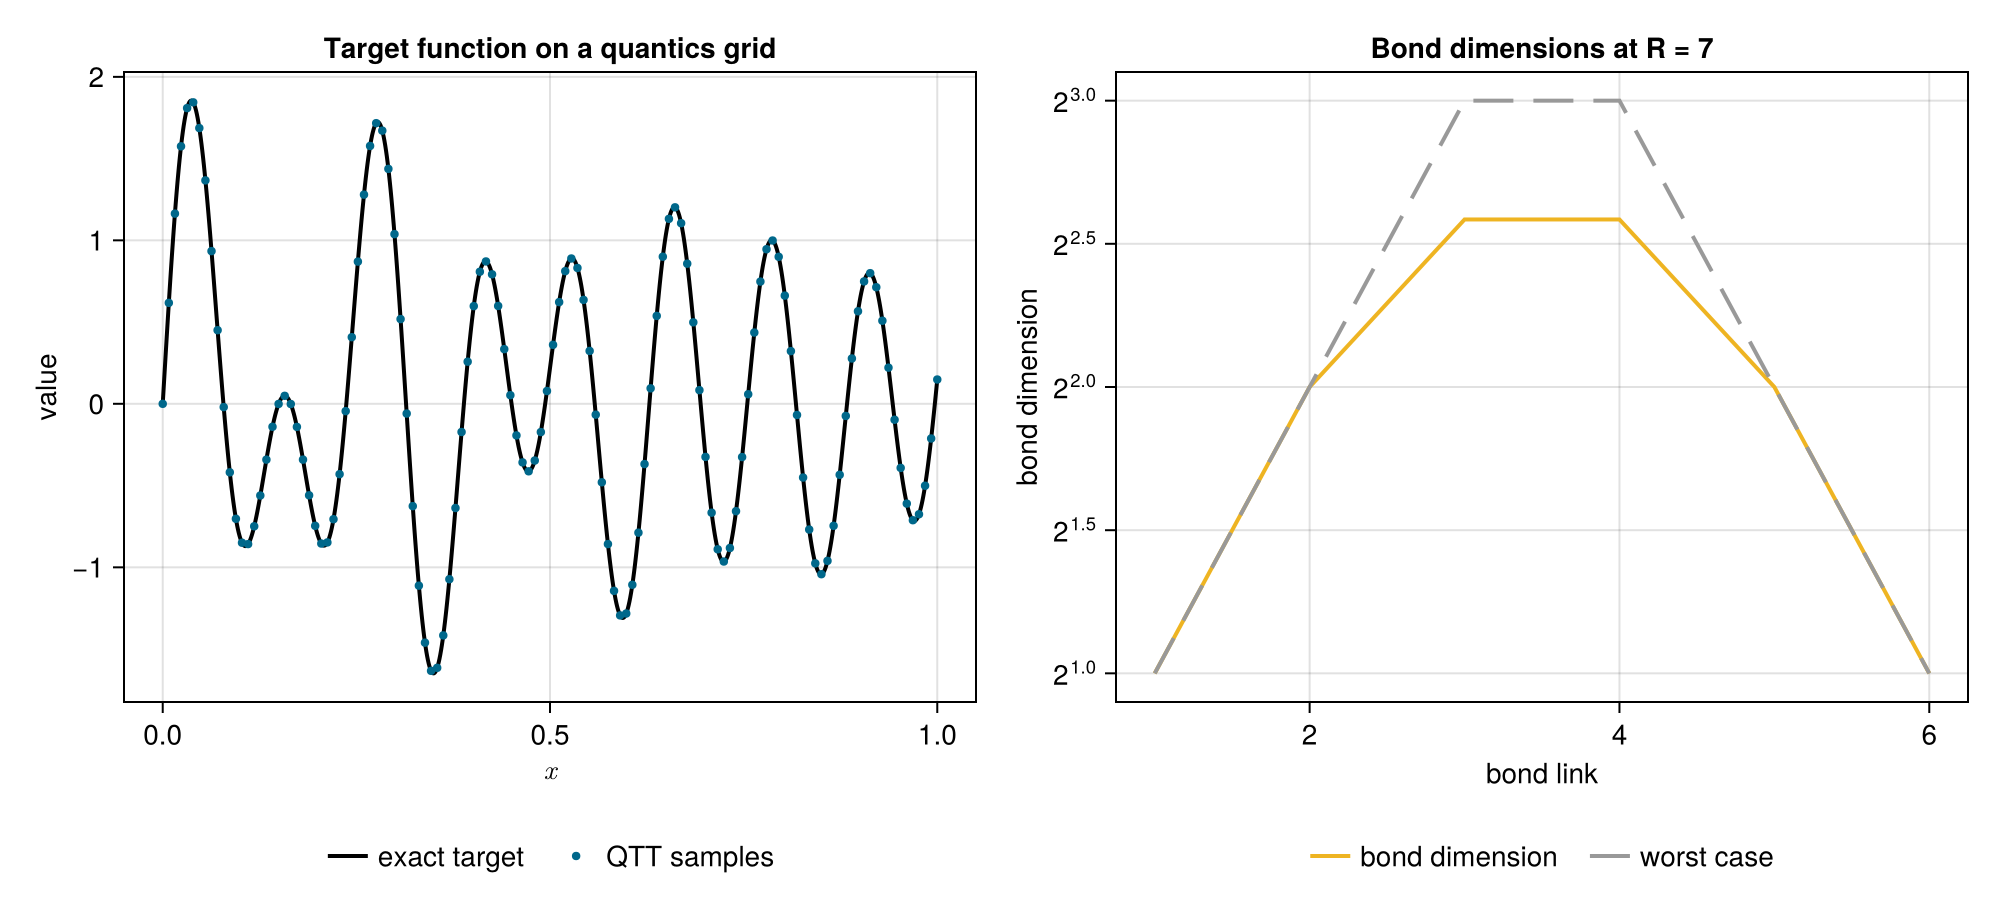

In [123]:
worst_case_bond_dims(num_bonds; base=2) =
    [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

fig = Figure(size=(1000, 460))

ax1 = Axis(
    fig[1, 1],
    xlabel=L"x",
    ylabel="value",
    title="Target function on a quantics grid",
)
xs = range(first(xvals), last(xvals), length=1000)
lines!(ax1, xs, target_function.(xs);
    color=:black, linewidth=2, label="exact target")
scatter!(ax1, xvals, qtt_values;
    color=:deepskyblue4, markersize=6, label="QTT samples")
Legend(fig[2, 1], ax1, orientation=:horizontal, framevisible=false)

ax2 = Axis(
    fig[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimensions at R = $R",
    yscale=log2,
)
bond_index = 1:length(bond_dims)
lines!(ax2, bond_index, bond_dims;
    color=:goldenrod2, linewidth=2, label="bond dimension")
lines!(ax2, bond_index, worst_case_bond_dims(length(bond_dims));
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig[2, 2], ax2, orientation=:horizontal, framevisible=false)

fig

The left panel shows the exact function and the QTT samples. The right panel shows the bond-dimension profile.

For this target function the bond dimensions are small. The worst-case envelope — what the bond dimensions would be for a generic unstructured function — is far higher. Already at this baseline we can see that the QTT has found a compact representation.

## 2. Sweep over R

Now we vary only `R` while keeping the target function, interval, `tolerance`, `maxbonddim`, and `maxiter` fixed.

`R` controls the bit depth and therefore the number of grid points (`npoints = 2^R`). A larger `R` gives a finer grid, but it does not automatically force the QTT to become structurally more complex. The question is: does more resolution help reduce the approximation error for this target?

In [124]:
sweep_R_values = [4, 5, 6, 7, 8, 9, 10]
sweep_R_max_abs_errors = Float64[]
sweep_R_all_bond_dims = []

for sweep_R in sweep_R_values
    sweep_npoints = 1 << sweep_R
    sweep_grid = QG.DiscretizedGrid{1}(sweep_R, 0.0, 1.0; includeendpoint=true)

    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        target_function,
        sweep_grid;
        tolerance=tolerance,
        maxbonddim=maxbonddim,
        maxiter=maxiter,
    )

    sweep_simple_tt = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(sweep_simple_tt)]
    sweep_indexed_tt = TN.TensorTrain(sweep_simple_tt, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed_tt)

    sweep_xvals = [QG.grididx_to_origcoord(sweep_grid, i) for i in 1:sweep_npoints]
    sweep_exact = target_function.(sweep_xvals)
    sweep_values = [real(sweep_qtt(i)) for i in 1:sweep_npoints]
    sweep_max_abs_error = maximum(abs.(sweep_exact .- sweep_values))
    sweep_max_bond_dim = maximum(sweep_bond_dims)

    push!(sweep_R_max_abs_errors, sweep_max_abs_error)
    push!(sweep_R_all_bond_dims, sweep_bond_dims)

    println("For R = $sweep_R, the maximum absolute error is " *
            "$sweep_max_abs_error and the maximum bond dimension " *
            "is $sweep_max_bond_dim.")
end

For R = 4, the maximum absolute error is 1.1102230246251565e-16 and the maximum bond dimension is 4.
For R = 5, the maximum absolute error is 1.6653345369377348e-16 and the maximum bond dimension is 4.
For R = 6, the maximum absolute error is 5.773159728050814e-15 and the maximum bond dimension is 6.
For R = 7, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For R = 8, the maximum absolute error is 4.884981308350689e-15 and the maximum bond dimension is 6.
For R = 9, the maximum absolute error is 2.2093438190040615e-14 and the maximum bond dimension is 6.
For R = 10, the maximum absolute error is 9.325873406851315e-15 and the maximum bond dimension is 6.


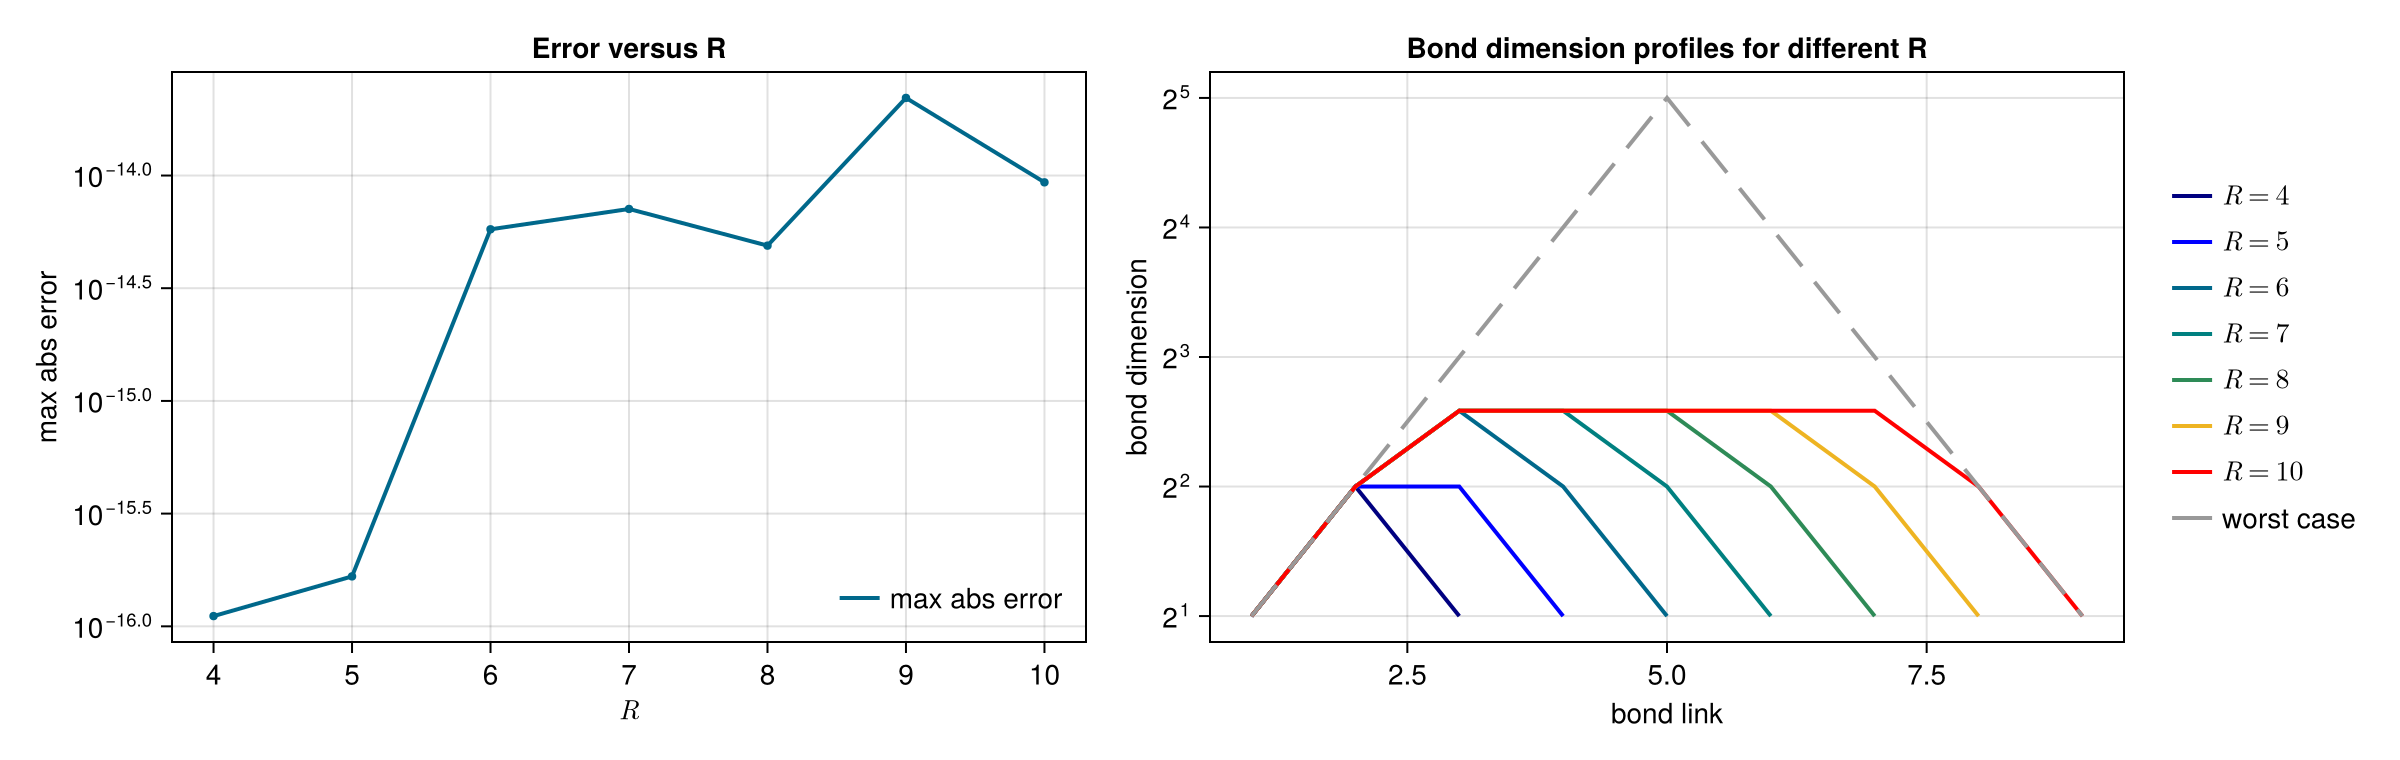

In [125]:
fig_R = Figure(size=(1200, 380))

axR1 = Axis(
    fig_R[1, 1],
    xlabel=L"R",
    ylabel="max abs error",
    title="Error versus R",
    yscale=log10,
)
lines!(axR1, sweep_R_values, sweep_R_max_abs_errors;
    color=:deepskyblue4, linewidth=2, label="max abs error")
scatter!(axR1, sweep_R_values, sweep_R_max_abs_errors;
    color=:deepskyblue4, markersize=6)
axislegend(axR1; position=:rb, framevisible=false)

axR2 = Axis(
    fig_R[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimension profiles for different R",
    yscale=log2,
)
palette = [:navy, :blue, :deepskyblue4, :teal, :seagreen, :goldenrod2, :red]
for (i, sweep_R) in enumerate(sweep_R_values)
    bond_profile = sweep_R_all_bond_dims[i]
    bond_idx = 1:length(bond_profile)
    lines!(axR2, bond_idx, bond_profile;
        color=palette[i], linewidth=2, label=L"R = %$sweep_R")
end
worst = worst_case_bond_dims(length(sweep_R_all_bond_dims[end]))
lines!(axR2, 1:length(worst), worst;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig_R[1, 3], axR2, framevisible=false)

fig_R

At very low `R` the grid is too coarse to resolve the oscillations of the target function, so the error is large (note the log10 y-scale on the left panel). As `R` increases, the error drops dramatically. The right panel shows bond dimension profiles for each R overlaid — the peak bond dimension grows with R because a longer quantics encoding can capture more structure.

This is the first key distinction: `R` changes the grid resolution, and for a sufficiently complex target a larger R can also expose more internal structure in the QTT.

## 3. Sweep over tolerance

Now we vary only `tolerance` while keeping `R`, `maxbonddim`, `maxiter`, and the target function fixed.

The tolerance tells the cross-interpolation algorithm how accurately to approximate the function. A stricter (smaller) tolerance should produce a more accurate QTT, but it may also require larger bond dimensions. Let us check how this tradeoff looks for our target function.

In [126]:
sweep_tolerance_values = [1e-4, 1e-6, 1e-8, 1e-10, 1e-12, 1e-14]
sweep_tol_max_abs_errors = Float64[]
sweep_tol_max_bond_dims = Int[]

for sweep_tolerance in sweep_tolerance_values
    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        target_function,
        grid;
        tolerance=sweep_tolerance,
        maxbonddim=maxbonddim,
        maxiter=maxiter,
    )

    sweep_simple_tt = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(sweep_simple_tt)]
    sweep_indexed_tt = TN.TensorTrain(sweep_simple_tt, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed_tt)

    sweep_values = [real(sweep_qtt(i)) for i in 1:npoints]
    sweep_max_abs_error = maximum(abs.(exact_values .- sweep_values))
    sweep_max_bond_dim = maximum(sweep_bond_dims)

    push!(sweep_tol_max_abs_errors, sweep_max_abs_error)
    push!(sweep_tol_max_bond_dims, sweep_max_bond_dim)

    println("For tolerance = $sweep_tolerance, the maximum " *
            "absolute error is $sweep_max_abs_error and the " *
            "maximum bond dimension is $sweep_max_bond_dim.")
end

For tolerance = 0.0001, the maximum absolute error is 0.00011526923131410793 and the maximum bond dimension is 6.
For tolerance = 1.0e-6, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For tolerance = 1.0e-8, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For tolerance = 1.0e-10, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For tolerance = 1.0e-12, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For tolerance = 1.0e-14, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.


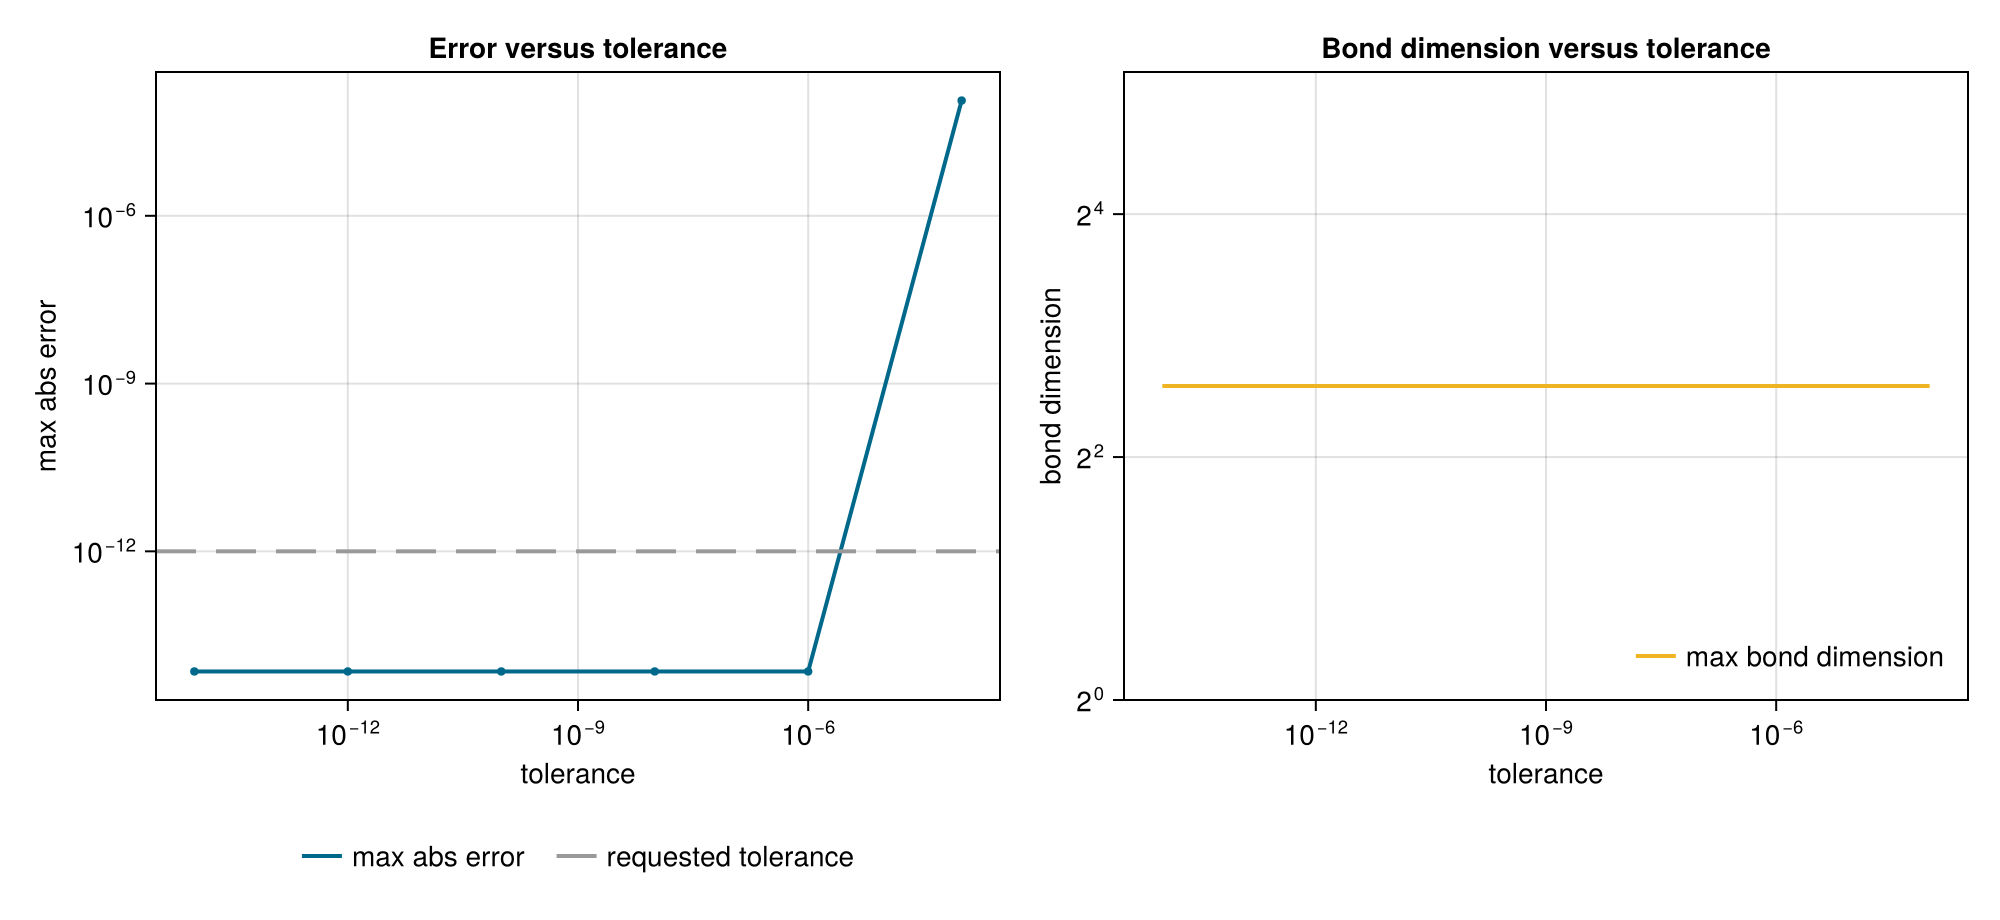

In [127]:
fig_tol = Figure(size=(1000, 460))

axtol1 = Axis(
    fig_tol[1, 1],
    xlabel="tolerance",
    ylabel="max abs error",
    title="Error versus tolerance",
    xscale=log10,
    yscale=log10,
)
lines!(axtol1, sweep_tolerance_values, sweep_tol_max_abs_errors;
    color=:deepskyblue4, linewidth=2, label="max abs error")
scatter!(axtol1, sweep_tolerance_values, sweep_tol_max_abs_errors;
    color=:deepskyblue4, markersize=6)
hlines!(axtol1, tolerance;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="requested tolerance")
Legend(fig_tol[2, 1], axtol1, orientation=:horizontal, framevisible=false)

axtol2 = Axis(
    fig_tol[1, 2],
    xlabel="tolerance",
    ylabel="bond dimension",
    title="Bond dimension versus tolerance",
    xscale=log10,
    yscale=log2,
)
lines!(axtol2, sweep_tolerance_values, sweep_tol_max_bond_dims;
    color=:goldenrod2, linewidth=2, label="max bond dimension")
axislegend(axtol2; position=:rb, framevisible=false)

fig_tol

For this target function the measured error follows the requested tolerance closely over a wide range. The maximum bond dimension stays fixed at 6 because the natural representation requires that much internal room, and tightening the tolerance does not demand more.

This is the second key distinction: `tolerance` controls the interpolation quality. A stricter tolerance can force larger bond dimensions for functions that need more internal room, but here the rank has already stabilized at the function's natural complexity.

## 4. Sweep over maxbonddim

Now we vary only `maxbonddim` while keeping everything else fixed.

`maxbonddim` is the artificial cap on how much internal room the QTT may use. If the cap is too small, the algorithm cannot represent the function accurately even when the grid and tolerance would otherwise be sufficient. How small is too small for this target?

In [128]:
sweep_maxbonddim_values = [1, 2, 4, 8, 16, 32]
sweep_mbd_max_abs_errors = Float64[]
sweep_mbd_max_bond_dims = Int[]

for sweep_maxbonddim in sweep_maxbonddim_values
    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        target_function,
        grid;
        tolerance=tolerance,
        maxbonddim=sweep_maxbonddim,
        maxiter=maxiter,
    )

    sweep_simple_tt = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(sweep_simple_tt)]
    sweep_indexed_tt = TN.TensorTrain(sweep_simple_tt, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed_tt)

    sweep_values = [real(sweep_qtt(i)) for i in 1:npoints]
    sweep_max_abs_error = maximum(abs.(exact_values .- sweep_values))
    sweep_max_bond_dim = maximum(sweep_bond_dims)

    push!(sweep_mbd_max_abs_errors, sweep_max_abs_error)
    push!(sweep_mbd_max_bond_dims, sweep_max_bond_dim)

    println("For maxbonddim = $sweep_maxbonddim, the maximum absolute error is " *
            "$sweep_max_abs_error and the maximum bond dimension " *
            "is $sweep_max_bond_dim.")
end

For maxbonddim = 1, the maximum absolute error is 1.360049976676847 and the maximum bond dimension is 1.
For maxbonddim = 2, the maximum absolute error is 0.956812594939589 and the maximum bond dimension is 2.
For maxbonddim = 4, the maximum absolute error is 0.01858093154110041 and the maximum bond dimension is 4.
For maxbonddim = 8, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For maxbonddim = 16, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.
For maxbonddim = 32, the maximum absolute error is 7.105427357601002e-15 and the maximum bond dimension is 6.


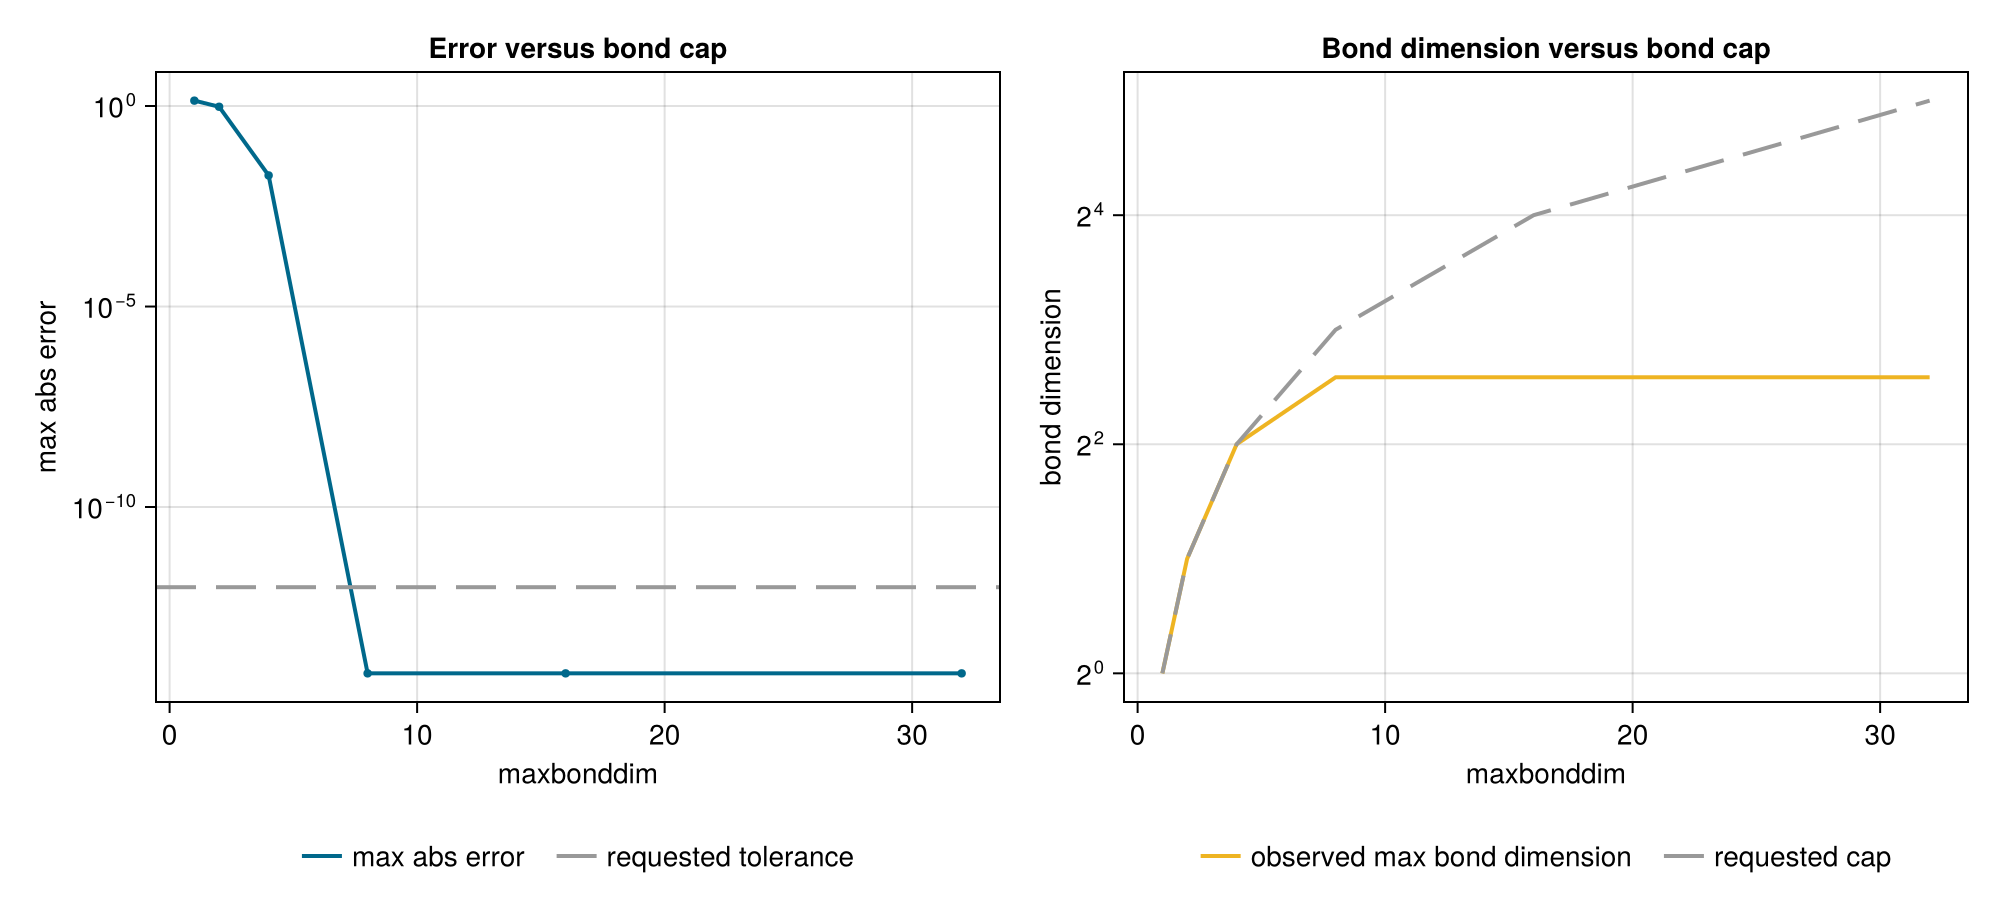

In [129]:
fig_mbd = Figure(size=(1000, 460))

axmbd1 = Axis(
    fig_mbd[1, 1],
    xlabel="maxbonddim",
    ylabel="max abs error",
    title="Error versus bond cap",
    yscale=log10,
)
lines!(axmbd1, sweep_maxbonddim_values, sweep_mbd_max_abs_errors;
    color=:deepskyblue4, linewidth=2, label="max abs error")
scatter!(axmbd1, sweep_maxbonddim_values, sweep_mbd_max_abs_errors;
    color=:deepskyblue4, markersize=6)
hlines!(axmbd1, tolerance;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="requested tolerance")
Legend(fig_mbd[2, 1], axmbd1, orientation=:horizontal, framevisible=false)

axmbd2 = Axis(
    fig_mbd[1, 2],
    xlabel="maxbonddim",
    ylabel="bond dimension",
    title="Bond dimension versus bond cap",
    yscale=log2,
)
lines!(axmbd2, sweep_maxbonddim_values, sweep_mbd_max_bond_dims;
    color=:goldenrod2, linewidth=2, label="observed max bond dimension")
lines!(axmbd2, sweep_maxbonddim_values, sweep_maxbonddim_values;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="requested cap")
Legend(fig_mbd[2, 2], axmbd2, orientation=:horizontal, framevisible=false)

fig_mbd

A cap of `1` is far too small — the QTT cannot represent the function accurately. At `2` and `4` the cap is still too tight: the algorithm is forced to stop early and the error remains large. Once the cap reaches `8`, the observed bond dimension reaches the natural rank of `6` and the error drops to the tolerance level. Larger caps do not help further because the representation has already stabilized.

This is the third key distinction: `maxbonddim` is an artificial limit. It can prevent the algorithm from finding a good approximation, but raising it beyond the natural rank of the function does not improve accuracy.

## 5. Two-function comparison

So far we have varied `R`, `tolerance`, and `maxbonddim` for the same target function. But the response to these parameters also depends on the structure of the function itself.

We compare `sin(30x)` with `cosh(x)` — a compact function whose QTT representation stays particularly small (as we saw in Notebook 01). Both use the same parameter settings.

In [130]:
comparison_functions = [x -> sin(30x)*cos(2x)+sin(50*x), x -> cosh(x)]
comparison_names = ["sin(30x)*cos(2x)+sin(50*x)", "cosh(x)"]

comparison_bond_dims_list = []
comparison_max_abs_errors = Float64[]

for (cf, cname) in zip(comparison_functions, comparison_names)
    c_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        cf,
        grid;
        tolerance=tolerance,
        maxbonddim=maxbonddim,
        maxiter=maxiter,
    )

    c_simple_tt = STT.TensorTrain(c_qtt.tci)
    c_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) 
        for i in 1:length(c_simple_tt)]
    c_indexed_tt = TN.TensorTrain(c_simple_tt, c_sites)
    c_bond_dims = TN.linkdims(c_indexed_tt)

    c_values = [real(c_qtt(i)) for i in 1:npoints]
    c_exact = cf.(xvals)
    c_max_abs_error = maximum(abs.(c_exact .- c_values))

    push!(comparison_bond_dims_list, c_bond_dims)
    push!(comparison_max_abs_errors, c_max_abs_error)

    println("$cname: max abs error = $c_max_abs_error, bond dims = $c_bond_dims")
end

sin(30x)*cos(2x)+sin(50*x): max abs error = 7.105427357601002e-15, bond dims = [2, 4, 6, 6, 4, 2]
cosh(x): max abs error = 4.440892098500626e-16, bond dims = [2, 2, 2, 2, 2, 2]


In [132]:
fig_comp = Figure(size=(1000, 460))

axc1 = Axis(
    fig_comp[1, 1],
    xlabel=L"x",
    ylabel="value",
    title="Two functions on [0, 1]",
)
xs_comp = range(0, 1, length=1000)
lines!(axc1, xs_comp, comparison_functions[1].(xs_comp);
    color=:black, linewidth=2, label=L"\\sin(30x)\\cos(2x) + \\sin(50x)")
lines!(axc1, xs_comp, comparison_functions[2].(xs_comp);
    color=:deepskyblue4, linewidth=2, label=L"\\cosh(x)")
Legend(fig_comp[2, 1], axc1, orientation=:horizontal, framevisible=false)

axc2 = Axis(
    fig_comp[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimensions compared",
    yscale=log2,
)
bond_index_1 = 1:length(comparison_bond_dims_list[1])
lines!(axc2, bond_index_1, comparison_bond_dims_list[1];
    color=:black, linewidth=2, label=L"\\sin(30x)\\cos(2x) + \\sin(50x)")
bond_index_2 = 1:length(comparison_bond_dims_list[2])
lines!(axc2, bond_index_2, comparison_bond_dims_list[2];
    color=:deepskyblue4, linewidth=2,
    label=L"\\cosh(x)")
lines!(axc2, bond_index, worst_case_bond_dims(length(bond_dims));
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig_comp[2, 2], axc2, orientation=:horizontal, framevisible=false)

fig_comp

ComputePipeline.ResolveException{MathTeXEngine.TeXParseError}: Error trying to display an error.

Both functions achieve low error under the same settings, but their bond-dimension profiles differ. `sin(30x)` uses bond dimension `2` throughout, while `cosh(x)` also stays very compact. Under a tighter tolerance or with a different function the difference could be larger.

The important point is that the response to `R`, `tolerance`, and `maxbonddim` is not the same for all functions. The structure of the function itself matters.

## What to notice

- `R` controls the grid resolution. More points can improve accuracy when the previous grid was too coarse, but higher `R` alone does not increase the internal complexity of the QTT.
- `tolerance` controls the interpolation quality. A stricter tolerance may lead to larger bond dimensions for functions that need more internal room.
- `maxbonddim` is an artificial cap. Setting it too low prevents the algorithm from finding an accurate approximation. Setting it above the natural rank does not help further.
- The three parameters serve different roles: grid resolution, interpolation quality, and artificial capacity limit. They should not be confused.
- Different functions can have very different bond-dimension profiles under the same parameter settings.

## API recap

- `Tensor4all.QuanticsGrids.DiscretizedGrid{1}`
- `Tensor4all.QuanticsGrids.grididx_to_origcoord`
- `Tensor4all.QuanticsTCI.quanticscrossinterpolate`
- `Tensor4all.SimpleTT.TensorTrain`
- `Tensor4all.TensorNetworks.TensorTrain`
- `Tensor4all.TensorNetworks.linkdims`
- `Tensor4all.Index`